In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict

# =============================================================================
# 0) Configuration block (2x2 grid)
# =============================================================================
PLOT_CFG = {
    "height": 2.5,
    "aspect": 1.5,
    "use_dashed": True,
    "linewidth": 2.0,
    "shade_alpha": 0.18,
    "style": "whitegrid",
    "palette": "deep",
    "dpi": 150,
    "xlabel": "Training Steps",
    "ylabel": "Accuracy (%)",
    "legend_fontsize": 9,
    "outfile": "result_single_vs_repeated_2x2.pdf",
}

TITLE_MAP = {
    'bioS_noise_0_base_250818-070540': "SINGLE",
    'bioS_noise_0_multiple-context_250818-124537': "REPEATED",
}

METRIC_MAP: Dict[str, str] = {
    'em/param':             r'$\mathrm{Acc}_{\mathrm{PKU}}$',
    'em/multi_ood_in_ctx':  r'$\mathrm{Acc}_{\mathrm{ICKU}}$',
    'em/pert_ctx_orig':     r'$\mathrm{Pref}_{\mathrm{PK}}$',
    'em/pert_ctx_pert':     r'$\mathrm{Pref}_{\mathrm{ICK}}$',
}

COLOR_MAP = {
    r'$\mathrm{Acc}_{\mathrm{PKU}}$': sns.color_palette("deep")[2],
    r'$\mathrm{Acc}_{\mathrm{ICKU}}$': sns.color_palette("deep")[0],
    r'$\mathrm{Pref}_{\mathrm{PK}}$':  sns.color_palette("deep")[3],
    r'$\mathrm{Pref}_{\mathrm{ICK}}$': sns.color_palette("deep")[1],
}

LINESTYLE_MAP = {
    r'$\mathrm{Acc}_{\mathrm{PKU}}$': (2, 2),
    r'$\mathrm{Acc}_{\mathrm{ICKU}}$': (2, 2),
    r'$\mathrm{Pref}_{\mathrm{PK}}$':  (1, 1),
    r'$\mathrm{Pref}_{\mathrm{ICK}}$': (1, 1),
}

# =============================================================================
# 1) Style setup
# =============================================================================
def setup_style() -> None:
    sns.set_theme(
        style=PLOT_CFG["style"],
        palette=PLOT_CFG["palette"],
        rc={
            "figure.dpi": PLOT_CFG["dpi"],
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "legend.fontsize": PLOT_CFG["legend_fontsize"],
            "lines.linewidth": PLOT_CFG["linewidth"],
        },
    )

# =============================================================================
# 2) Data loading & statistics aggregation
# =============================================================================
def load_stats(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    rename_cols = {k: v for k, v in METRIC_MAP.items() if k in df.columns}
    df = df.rename(columns=rename_cols)
    metrics = list(rename_cols.values())

    long_seed = pd.melt(
        df,
        id_vars=["model", "step", "seed"],
        value_vars=metrics,
        var_name="Metric",
        value_name="Accuracy",
    )

    if long_seed["Accuracy"].max() <= 1.0:
        long_seed["Accuracy"] *= 100.0

    long_seed["Model_Title"] = long_seed["model"].map(TITLE_MAP).fillna(long_seed["model"])

    stats = (
        long_seed
        .groupby(["model", "Model_Title", "step", "Metric"], as_index=False)
        .agg(Mean=("Accuracy", "mean"),
             Std=("Accuracy", "std"),
             N=("Accuracy", "count"))
        .sort_values(["Model_Title", "Metric", "step"])
        .reset_index(drop=True)
    )
    return stats

# =============================================================================
# 3) 2x2 FacetGrid plotting
# =============================================================================
def plot_2x2_facet(stats_df: pd.DataFrame) -> None:
    # Add metric type (Acc / Pref) column
    acc_metrics = [r'$\mathrm{Acc}_{\mathrm{PKU}}$', r'$\mathrm{Acc}_{\mathrm{ICKU}}$']
    pref_metrics = [r'$\mathrm{Pref}_{\mathrm{PK}}$', r'$\mathrm{Pref}_{\mathrm{ICK}}$']
    
    df = stats_df.copy()
    df["MetricType"] = df["Metric"].apply(
        lambda x: "Acc" if x in acc_metrics else ("Pref" if x in pref_metrics else None)
    )
    df = df.dropna(subset=["MetricType"])
    
    # Filter SINGLE, REPEATED only
    df = df[df["Model_Title"].isin(["SINGLE", "REPEATED"])]
    
    # FacetGrid: row=MetricType, col=Model_Title
    g = sns.FacetGrid(
        df,
        row="MetricType",
        col="Model_Title",
        row_order=["Acc", "Pref"],
        col_order=["SINGLE", "REPEATED"],
        sharey="row",
        sharex=True,
        height=PLOT_CFG["height"],
        aspect=PLOT_CFG["aspect"],
        margin_titles=False,
    )

    def facet_plot(data, **kwargs):
        ax = plt.gca()
        for metric, mdf in data.groupby("Metric", sort=False):
            mdf = mdf.sort_values("step")
            ax.plot(
                mdf["step"],
                mdf["Mean"],
                label=metric,
                color=COLOR_MAP[metric],
                dashes=LINESTYLE_MAP[metric],
            )
            ax.fill_between(
                mdf["step"],
                mdf["Mean"] - mdf["Std"],
                mdf["Mean"] + mdf["Std"],
                color=COLOR_MAP[metric],
                alpha=PLOT_CFG["shade_alpha"],
            )

    g.map_dataframe(facet_plot)

    # Title, label, legend settings
    for ax in g.axes.flat:
        ax.grid(alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, fontsize=PLOT_CFG["legend_fontsize"], loc="center right", frameon=True)
    
    # Top row titles (SINGLE, REPEATED)
    for ax, title in zip(g.axes[0], ["SINGLE", "REPEATED"]):
        ax.set_title(title, fontsize=13, weight="bold", style="italic")
    
    # Remove titles for bottom row
    for ax in g.axes[1]:
        ax.set_title("")
    
    # Set x, y labels
    for ax in g.axes[1]:
        ax.set_xlabel(PLOT_CFG["xlabel"])
    for ax in g.axes[:, 0]:
        ax.set_ylabel(PLOT_CFG["ylabel"])

    g.fig.tight_layout()
    g.fig.savefig(PLOT_CFG["outfile"], bbox_inches="tight", format="pdf")
    print(f"Saved 2x2 FacetGrid plot as {PLOT_CFG['outfile']}")
    plt.show()

# =============================================================================
# 4) Execution
# =============================================================================
if __name__ == "__main__":
    setup_style()
    df_stats = load_stats("gpt2train/probe_results_multi.csv")
    plot_2x2_facet(df_stats)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict

# =============================================================================
# 0) Configuration block (data/metrics same as original code)
# =============================================================================
PLOT_CFG = {
    "height": 2.0,
    "aspect": 1.7,
    "use_dashed": True,
    "linewidth": 2.0,
    "shade_alpha": 0.18,
    "style": "whitegrid",
    "palette": "deep",
    "dpi": 150,
    "xlabel": "Training Steps",
    "ylabel": "Accuracy (%)",
    "legend_fontsize": 10,
    "outfile": "result_single_vs_repeated.pdf",
}

TITLE_MAP = {
    'bioS_noise_0_base_250818-070540': "SINGLE",
    'bioS_noise_0_multiple-context_250818-124537': "REPEATED",
}

METRIC_MAP: Dict[str, str] = {
    'em/param':             r'$\mathrm{Acc}_{\mathrm{PKU}}$',
    'em/multi_ood_in_ctx':  r'$\mathrm{Acc}_{\mathrm{ICKU}}$',
    'em/pert_ctx_orig':     r'$\mathrm{Pref}_{\mathrm{PK}}$',
    'em/pert_ctx_pert':     r'$\mathrm{Pref}_{\mathrm{ICK}}$',
}

COLOR_MAP = {
    r'$\mathrm{Acc}_{\mathrm{PKU}}$': sns.color_palette("deep")[2],
    r'$\mathrm{Acc}_{\mathrm{ICKU}}$': sns.color_palette("deep")[0],
    r'$\mathrm{Pref}_{\mathrm{PK}}$':  sns.color_palette("deep")[3],
    r'$\mathrm{Pref}_{\mathrm{ICK}}$': sns.color_palette("deep")[1],
}

LINESTYLE_MAP = {
    r'$\mathrm{Acc}_{\mathrm{PKU}}$': (2, 2),
    r'$\mathrm{Acc}_{\mathrm{ICKU}}$': (2, 2),
    r'$\mathrm{Pref}_{\mathrm{PK}}$':  (1, 1),
    r'$\mathrm{Pref}_{\mathrm{ICK}}$': (1, 1),
}

PANEL_TITLE_MAP = {
    "SINGLE": "SINGLE",
    "REPEATED_ACC": "REPEATED",
    "REPEATED_PREF": "REPEATED",
}

# =============================================================================
# 1) Style setup
# =============================================================================
def setup_style() -> None:
    sns.set_theme(
        style=PLOT_CFG["style"],
        palette=PLOT_CFG["palette"],
        rc={
            "figure.dpi": PLOT_CFG["dpi"],
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "legend.fontsize": PLOT_CFG["legend_fontsize"],
            "lines.linewidth": PLOT_CFG["linewidth"],
        },
    )

# =============================================================================
# 2) Data loading & statistics aggregation
# =============================================================================
def load_stats(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    rename_cols = {k: v for k, v in METRIC_MAP.items() if k in df.columns}
    df = df.rename(columns=rename_cols)
    metrics = list(rename_cols.values())

    long_seed = pd.melt(
        df,
        id_vars=["model", "step", "seed"],
        value_vars=metrics,
        var_name="Metric",
        value_name="Accuracy",
    )

    if long_seed["Accuracy"].max() <= 1.0:
        long_seed["Accuracy"] *= 100.0

    long_seed["Model_Title"] = long_seed["model"].map(TITLE_MAP).fillna(long_seed["model"])

    stats = (
        long_seed
        .groupby(["model", "Model_Title", "step", "Metric"], as_index=False)
        .agg(Mean=("Accuracy", "mean"),
             Std=("Accuracy", "std"),
             N=("Accuracy", "count"))
        .sort_values(["Model_Title", "Metric", "step"])
        .reset_index(drop=True)
    )
    return stats

# =============================================================================
# 3) Panel column creation
# =============================================================================
def add_panel_column(stats_df: pd.DataFrame) -> pd.DataFrame:
    df = stats_df.copy()
    df["Panel"] = None

    acc_metrics = [r'$\mathrm{Acc}_{\mathrm{PKU}}$', r'$\mathrm{Acc}_{\mathrm{ICKU}}$']
    pref_metrics = [r'$\mathrm{Pref}_{\mathrm{PK}}$', r'$\mathrm{Pref}_{\mathrm{ICK}}$']

    df.loc[(df["Model_Title"] == "SINGLE") &
           (df["Metric"].isin(acc_metrics)), "Panel"] = "SINGLE"

    df.loc[(df["Model_Title"] == "REPEATED") &
           (df["Metric"].isin(acc_metrics)), "Panel"] = "REPEATED_ACC"

    df.loc[(df["Model_Title"] == "REPEATED") &
           (df["Metric"].isin(pref_metrics)), "Panel"] = "REPEATED_PREF"

    return df.dropna(subset=["Panel"])

# =============================================================================
# 4) FacetGrid plotting (individual legend per panel)
# =============================================================================
def plot_three_facet(stats_df: pd.DataFrame) -> None:
    data = add_panel_column(stats_df)

    g = sns.FacetGrid(
        data,
        col="Panel",
        col_order=["SINGLE", "REPEATED_ACC", "REPEATED_PREF"],
        sharey=True,
        height=PLOT_CFG["height"],
        aspect=PLOT_CFG["aspect"],
        margin_titles=False,
    )

    def facet_plot(data, **kwargs):
        ax = plt.gca()

        for metric, mdf in data.groupby("Metric", sort=False):
            mdf = mdf.sort_values("step")

            ax.plot(
                mdf["step"],
                mdf["Mean"],
                label=metric,
                color=COLOR_MAP[metric],
                dashes=LINESTYLE_MAP[metric],
            )

            ax.fill_between(
                mdf["step"],
                mdf["Mean"] - mdf["Std"],
                mdf["Mean"] + mdf["Std"],
                color=COLOR_MAP[metric],
                alpha=PLOT_CFG["shade_alpha"],
            )

    g.map_dataframe(facet_plot)

    # Per-panel legend + style
    for ax, panel_name in zip(g.axes.flat, ["SINGLE", "REPEATED_ACC", "REPEATED_PREF"]):
        ax.set_title(PANEL_TITLE_MAP[panel_name], fontsize=13, weight="bold", style="italic")
        ax.set_xlabel(PLOT_CFG["xlabel"])
        ax.grid(alpha=0.3)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=PLOT_CFG["legend_fontsize"], loc="center right", frameon=True)

    g.axes.flat[0].set_ylabel(PLOT_CFG["ylabel"])

    g.fig.tight_layout()
    g.fig.savefig(PLOT_CFG["outfile"], bbox_inches="tight", format="pdf")
    print(f"Saved FacetGrid plot as {PLOT_CFG['outfile']}")
    plt.show()

# =============================================================================
# 5) Execution
# =============================================================================
if __name__ == "__main__":
    setup_style()
    df_stats = load_stats("gpt2train/probe_results_multi.csv")
    plot_three_facet(df_stats)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict, List

# =============================================================================
# 0) Single configuration block
# =============================================================================
PLOT_CFG = {
    "height": 2.0,
    "aspect": 1.7,
    "use_dashed": True,
    "linewidth": 2.0,
    "shade_alpha": 0.18,
    "style": "whitegrid",
    "palette": "deep",
    "dpi": 150,
    "xlabel": "Training Steps",
    "ylabel": "Accuracy (%)",
    "legend_out": True,
    "legend_loc": "center left",
    "legend_bbox": (1.02, 0.5),
    "legend_ncol": 1,
    "legend_fontsize": 11,
    "right_pad": 1,
    "outfile": "result_noise01_only_1percent.pdf",
}

# =============================================================================
# 1) Model name -> panel title
# =============================================================================
TITLE_MAP: Dict[str, str] = {
    'bioS_noise_0_multiple-context_250818-124537': "without noise",
    'bioS_noise_1_multiple-context_passage-noise_250816-095848': "1% noise",
}

# =============================================================================
# 2) CSV column name -> legend labels
# =============================================================================
METRIC_MAP: Dict[str, str] = {
    'em/param': r'$\mathrm{Acc}_{\mathrm{PKU}}$',
    'em/multi_ood_in_ctx': r'$\mathrm{Acc}_{\mathrm{ICKU}}$',
    'em/pert_ctx_orig': r'$\mathrm{Pref}_{\mathrm{PK}}$',
    'em/pert_ctx_pert': r'$\mathrm{Pref}_{\mathrm{ICK}}$',
}

# =============================================================================
# 3) Color / style
# =============================================================================
COLOR_MAP = {
    r'$\mathrm{Acc}_{\mathrm{PKU}}$': sns.color_palette("deep")[2],
    r'$\mathrm{Acc}_{\mathrm{ICKU}}$': sns.color_palette("deep")[0],
    r'$\mathrm{Pref}_{\mathrm{PK}}$':  sns.color_palette("deep")[3],
    r'$\mathrm{Pref}_{\mathrm{ICK}}$': sns.color_palette("deep")[1],
}

LINESTYLE_MAP = {
    r'$\mathrm{Acc}_{\mathrm{PKU}}$': (2, 2),
    r'$\mathrm{Acc}_{\mathrm{ICKU}}$': (2, 2),
    r'$\mathrm{Pref}_{\mathrm{PK}}$':  (2, 4),
    r'$\mathrm{Pref}_{\mathrm{ICK}}$': (2, 4),
}

# =============================================================================
# 4) Style setup
# =============================================================================
def setup_style() -> None:
    sns.set_theme(
        style=PLOT_CFG["style"],
        palette=PLOT_CFG["palette"],
        rc={
            "figure.dpi": PLOT_CFG["dpi"],
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "legend.fontsize": PLOT_CFG["legend_fontsize"],
            "lines.linewidth": PLOT_CFG["linewidth"],
        }
    )

# =============================================================================
# 5) Load data
# =============================================================================
def load_stats(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    rename_cols = {k: v for k, v in METRIC_MAP.items() if k in df.columns}
    df = df.rename(columns=rename_cols)

    metrics = list(rename_cols.values())

    long_seed = pd.melt(
        df,
        id_vars=["model", "step", "seed"],
        value_vars=metrics,
        var_name="Metric",
        value_name="Accuracy",
    )

    # 0-1 -> % conversion
    if long_seed["Accuracy"].max() <= 1.0:
        long_seed["Accuracy"] *= 100.0

    long_seed["Model_Title"] = long_seed["model"].map(TITLE_MAP).fillna(long_seed["model"])

    stats = (
        long_seed
        .groupby(["model", "Model_Title", "step", "Metric"], as_index=False)
        .agg(Mean=("Accuracy", "mean"),
             Std=("Accuracy", "std"),
             N=("Accuracy", "count"))
        .sort_values(["Model_Title", "Metric", "step"])
        .reset_index(drop=True)
    )
    return stats

# =============================================================================
# 6) Plot function (single panel output)
# =============================================================================
def plot_with_std(stats_df: pd.DataFrame, models: List[str], outfile: str = None) -> None:
    model_titles = [TITLE_MAP.get(m, m) for m in models]

    # --- Extract only the selected model ---
    data = stats_df[stats_df["Model_Title"].isin(model_titles)].copy()

    if data.empty:
        print("No data for selected model")
        return

    # FacetGrid -> only 1 panel created
    g = sns.FacetGrid(
        data,
        col="Model_Title",
        col_order=model_titles,
        height=PLOT_CFG["height"],
        aspect=PLOT_CFG["aspect"],
        sharey=True,
        margin_titles=False
    )

    # --- Line + std shading ---
    for ax, title in zip(g.axes.flat, model_titles):
        sub = data[data["Model_Title"] == title]

        for metric, mdf in sub.groupby("Metric", sort=False):
            mdf = mdf.sort_values("step")
            x, y, s = mdf["step"], mdf["Mean"], mdf["Std"]
            color = COLOR_MAP[metric]

            ax.plot(
                x, y,
                label=metric,
                color=color,
                dashes=LINESTYLE_MAP[metric],
            )
            ax.fill_between(x, y - s, y + s, color=color, alpha=PLOT_CFG["shade_alpha"])

        ax.set_title(title, fontsize=14, weight="bold", style="italic")
        ax.set_xlabel(PLOT_CFG["xlabel"])
        ax.grid(True, alpha=0.3)

    g.axes.flat[0].set_ylabel(PLOT_CFG["ylabel"])

    # --- Legend outside figure ---
    if PLOT_CFG["legend_out"]:
        handles, labels = g.axes.flat[0].get_legend_handles_labels()

        g.fig.legend(
            handles, labels,
            loc=PLOT_CFG["legend_loc"],
            bbox_to_anchor=PLOT_CFG["legend_bbox"],
            ncol=PLOT_CFG["legend_ncol"],
            fontsize=PLOT_CFG["legend_fontsize"],
            frameon=True,
        )
        g.fig.subplots_adjust(right=PLOT_CFG["right_pad"])

    # Remove inner legend
    for ax in g.axes.flat:
        leg = ax.get_legend()
        if leg:
            leg.remove()

    out = outfile or PLOT_CFG["outfile"]
    g.fig.savefig(out, dpi=PLOT_CFG["dpi"], bbox_inches="tight")
    print(f"Saved figure as: {out}")
    plt.show()

# =============================================================================
# 7) Execution
# =============================================================================
if __name__ == "__main__":
    setup_style()
    stats_df = load_stats("gpt2train/probe_results_multi.csv")

    # Modified section: display only 1% noise model
    models_to_display = [
        'bioS_noise_1_multiple-context_passage-noise_250816-095848'
    ]

    plot_with_std(stats_df, models_to_display)

In [ ]:
# bars_acc_icku_last.py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

CSV_PATH   = "gpt2train/probe_results_multi.csv"
METRIC_COL = "em/multi_ood_in_ctx"   # ACC_ICKU

MODEL_IDS = [
    'bioS_noise_0_multiple-context_250818-124537',
    'bioS_noise_1_multiple-context_passage-noise_250816-095848',
    'bioS_noise_5_multiple-context_passage-noise_250816-125421',
    'bioS_noise_10_multiple-context_passage-noise_250816-155036',
]
MODEL_LABELS = {
    'bioS_noise_0_multiple-context_250818-124537':  "0%",
    'bioS_noise_1_multiple-context_passage-noise_250816-095848':  "1%",
    'bioS_noise_5_multiple-context_passage-noise_250816-125421':  "5%",
    'bioS_noise_10_multiple-context_passage-noise_250816-155036': "10%",
}
ORDER = ["0%", "1%", "5%", "10%"]

sns.set_theme(style="whitegrid", rc={
    "figure.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Load data
df = pd.read_csv(CSV_PATH)

# Percent scale correction
if METRIC_COL in df.columns and df[METRIC_COL].max() <= 1.0:
    df[METRIC_COL] *= 100.0

# Extract last checkpoint per model (preserving seed values)
rows = []
for mid in MODEL_IDS:
    sub = df[df["model"] == mid].copy()
    if sub.empty:
        continue
    last_step = sub["step"].max()
    sub_last  = sub[sub["step"] == last_step][["model", "seed", METRIC_COL]].copy()
    sub_last["label"] = MODEL_LABELS.get(mid, mid)
    rows.append(sub_last)

if rows:
    last_df = pd.concat(rows, ignore_index=True)
    last_df = last_df.dropna(subset=[METRIC_COL])
    last_df["label"] = pd.Categorical(last_df["label"], categories=ORDER, ordered=True)
else:
    last_df = pd.DataFrame(columns=["model", "seed", METRIC_COL, "label"])

# Summary output (optional)
if not last_df.empty:
    summary = (
        last_df.groupby("label", as_index=False)[METRIC_COL]
               .agg(mean="mean", std="std", n="count")
               .sort_values("label")
    )
    print(summary.round(2))
else:
    print("No data for bar chart.")

# Plotting
fig, ax = plt.subplots(figsize=(2.5, 2.5))
sns.barplot(
    data=last_df,
    x="label", y=METRIC_COL,
    order=ORDER,
    estimator=np.mean,
    errorbar="sd",     # standard deviation error bars
    capsize=0.2,
    width=0.7,
    ax=ax
)
ax.set_xlabel("Noise")
ax.set_ylabel(r'$\mathrm{Acc}_{\mathrm{ICKU}}$' + "(%)")
# ax.set_title(r'$\mathrm{Acc}_{\mathrm{ICKU}}$' + " at End of Training", weight="bold", style="italic")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.savefig("bars_acc_icku_last.pdf", bbox_inches="tight", dpi=300)
plt.show()

[Saved] prob_vs_prefpk_all.png
[Saved] prob_vs_prefpk_all.pdf


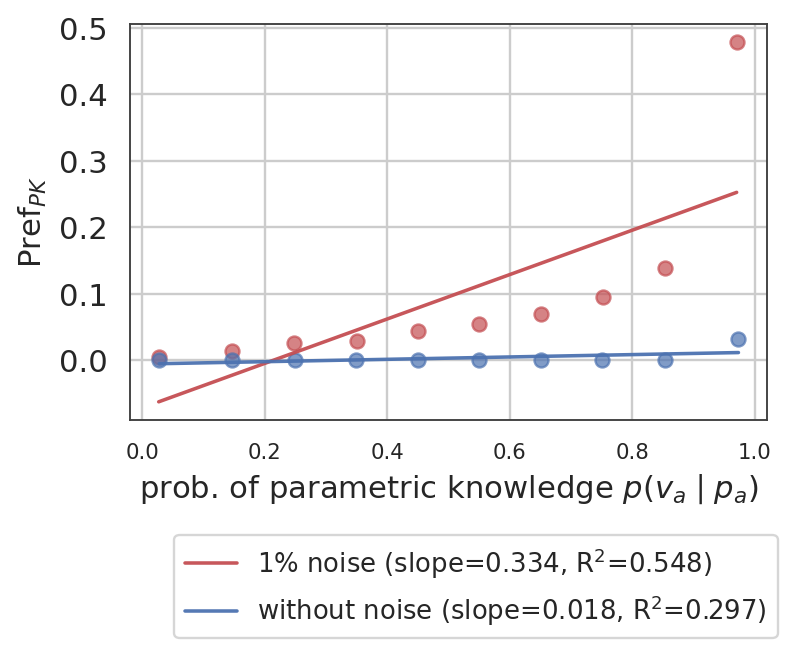

In [5]:
##!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Binned prob vs Pref_PK Accuracy (Seaborn style)
 - All attrs combined into one plot
 - Y axis = Pref_PK (no percentage)
 - Legend placed below the plot
 - Uses R^2 instead of R
 - Saves figure as PNG/PDF
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from pathlib import Path

logging.basicConfig(level=logging.INFO)
log = logging.getLogger("plot_prob_vs_prefpk")

# ===== Seaborn style =====
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.dpi": 170,
        "axes.titlesize": 13,
        "axes.labelsize": 13,
        "xtick.labelsize": 9,
        "ytick.labelsize": 13,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 0.8,
    }
)

POINT_ALPHA = 0.7
LINE_ALPHA  = 0.95

CSV_INFOS = [
    {
        "path": "./gpt2train/fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_1_250816-151409.csv",
        "label": "1% noise",
    },
    {
        "path": "./gpt2train/fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_0_250816-104331.csv",
        "label": "without noise",
    },
]

NUM_BINS = 10

palette = sns.color_palette("deep")
RUN_COLOR = {
    "1% noise":      palette[3],
    "without noise": palette[0],
}

# Load CSVs
dfs = [pd.read_csv(info["path"]) for info in CSV_INFOS]

per_run_data = []
all_x = []

# gather runs (all attrs combined)
for info, df in zip(CSV_INFOS, dfs):
    if "prob_param" not in df.columns or "correct_pert_ctx_orig" not in df.columns:
        continue

    x = df["prob_param"].astype(float).values
    y = df["correct_pert_ctx_orig"].astype(float).values  # <-- NO % conversion

    mask = np.isfinite(x)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        continue

    per_run_data.append({"label": info["label"], "x": x, "y": y})
    all_x.append(x)

if per_run_data:
    # Shared bins
    all_x_concat = np.concatenate(all_x)
    x_min, x_max = all_x_concat.min(), all_x_concat.max()
    bins = np.linspace(x_min, x_max, NUM_BINS + 1)

    fig, ax = plt.subplots(1, 1, figsize=(4.8, 3.4))

    legend_items = {}
    legend_labels = {}

    # Plot per run
    for run in per_run_data:
        label = run["label"]
        x = run["x"]
        y = run["y"]
        color = RUN_COLOR[label]

        bin_idx = np.digitize(x, bins, right=False) - 1
        bin_idx = np.clip(bin_idx, 0, NUM_BINS - 1)

        bx, by = [], []
        for b in range(NUM_BINS):
            mask_b = (bin_idx == b)
            if not np.any(mask_b):
                continue
            bx.append(x[mask_b].mean())
            by.append(y[mask_b].mean())

        bx = np.array(bx)
        by = np.array(by)

        if len(bx) < 2:
            continue

        # R^2 & slope
        R = np.corrcoef(bx, by)[0, 1]
        R2 = R ** 2
        coef = np.polyfit(bx, by, 1)
        slope = coef[0]

        x_line = np.linspace(bx.min(), bx.max(), 100)
        y_line = np.polyval(coef, x_line)

        # scatter
        ax.scatter(bx, by, s=35, alpha=POINT_ALPHA, color=color)

        # regression line
        handle, = ax.plot(
            x_line, y_line,
            alpha=LINE_ALPHA,
            color=color
        )

        legend_items[label] = handle
        legend_labels[label] = f"{label} (slope={slope:.3f}, R$^2$={R2:.3f})"

    # Labels
    ax.set_xlabel(r"prob. of parametric knowledge $p(v_a \mid p_a)$")
    ax.set_ylabel(r"$\mathrm{Pref}_{PK}$")
    # ax.set_title("All Attributes", fontweight="bold", fontstyle="italic")

    # Legend below
    handles = [legend_items[k] for k in legend_labels.keys()]
    labels  = [legend_labels[k]  for k in legend_labels.keys()]

    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.6, -0.15),
        ncol=1,
        frameon=True,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)

    # ===== SAVE figure =====
    png_name = "prob_vs_prefpk_all.png"
    pdf_name = "prob_vs_prefpk_all.pdf"

    fig.savefig(png_name, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_name, bbox_inches="tight")

    print(f"[Saved] {png_name}")
    print(f"[Saved] {pdf_name}")

    plt.show()
else:
    print("No valid data found.")


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Binned prob vs Pref_PK Accuracy for post-training scenarios.

Scenario 1:
  - before: pretrained zipf + 1% noise (100_1)
  - after : clean IT post-train result (1 model)
  -> One plot with both curves, legend to the right

Scenario 2:
  - before: pretrained zipf + 0% noise (100_0)
  - after : automatically discovers best-slope runs (noised IT, attrMut*)
  -> One plot with before + selected after runs, legend to the right
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
import re

logging.basicConfig(level=logging.INFO)
log = logging.getLogger("posttrain_corr")

# ===== Common style =====
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.dpi": 170,
        "axes.titlesize": 13,
        "axes.labelsize": 13,
        "xtick.labelsize": 9,
        "ytick.labelsize": 13,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 0.8,
    }
)

POINT_ALPHA = 0.7
LINE_ALPHA  = 0.95
NUM_BINS    = 10

# ========================================================
# Scenario 1 (Default path settings)
# ========================================================

SCEN1_CSVS = {
    "before (1% noise)": "/home/minsungkim/workspace/mpi-sp/gpt2train/fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_1_250816-151409.csv",
    "after (clean IT)": "/home/minsungkim/workspace/mpi-sp/gpt2train/fullprob_PARAMvsPERTctxORIG_ALL_noLOG__final_direct.csv"
}

# ========================================================
# Scenario 2 BEFORE
# ========================================================

SCEN2_BEFORE_LABEL = "before (0% noise)"
SCEN2_BEFORE_CSV   = "/home/minsungkim/workspace/mpi-sp/gpt2train/fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_0_250816-104331.csv"

# AFTER search directory
SCEN2_AFTER_SEARCH_DIR = Path("/home/minsungkim/workspace/mpi-sp/gpt2train/fullprob_param_vs_pertctxorig_results")

# File pattern
POSTTRAIN_REGEX = re.compile(
    r"fullprob_PARAMvsPERTctxORIG_ALL_noLOG_"
    r"posttrain_T1000_U0_noised_IT_ctxNoise1\.000_"
    r"attrMut(?P<attr>[0-9.]+)_sft_[0-9\-]+\.csv$"
)

# ========================================================
# Helper
# ========================================================

def load_birthdate_xy(csv_path):
    """Load birth_date attribute only."""
    df = pd.read_csv(csv_path)
    sub = df[df["attr"] == "birth_date"]
    x = sub["prob_param"].astype(float).to_numpy()
    y = sub["correct_pert_ctx_orig"].astype(float).to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def bin_xy(x, y, bins):
    idx = np.digitize(x, bins) - 1
    idx = np.clip(idx, 0, len(bins)-2)

    bx, by = [], []
    for b in range(len(bins)-1):
        m = idx == b
        if np.any(m):
            bx.append(x[m].mean())
            by.append(y[m].mean())
    return np.array(bx), np.array(by)


def compute_slope(bx, by):
    if len(bx) < 2:
        return np.nan
    coef = np.polyfit(bx, by, 1)
    return coef[0]


# ========================================================
# Scenario 1 Plot
# ========================================================

def plot_scenario1():
    before_csv = SCEN1_CSVS["before (1% noise)"]
    after_csv  = SCEN1_CSVS["after (clean IT)"]

    x_b, y_b = load_birthdate_xy(before_csv)
    x_a, y_a = load_birthdate_xy(after_csv)

    all_x = np.concatenate([x_b, x_a])
    bins  = np.linspace(all_x.min(), all_x.max(), NUM_BINS + 1)

    bx_b, by_b = bin_xy(x_b, y_b, bins)
    bx_a, by_a = bin_xy(x_a, y_a, bins)

    fig, ax = plt.subplots(figsize=(5.4, 3.6))

    # before = always black
    ax.scatter(bx_b, by_b, s=35, alpha=POINT_ALPHA, color="black")
    coef = np.polyfit(bx_b, by_b, 1)
    xs = np.linspace(bx_b.min(), bx_b.max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color="black", alpha=LINE_ALPHA,
            label="before (1% noise)")

    # after = deep palette[0]
    color = sns.color_palette("deep")[0]
    ax.scatter(bx_a, by_a, s=35, alpha=POINT_ALPHA, color=color)
    coef = np.polyfit(bx_a, by_a, 1)
    xs = np.linspace(bx_a.min(), bx_a.max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color=color, alpha=LINE_ALPHA,
            label="after (0% noise)")

    ax.set_xlabel(r"prob. of parametric knowledge $p(v_a \mid p_a)$")
    ax.set_ylabel(r"$\mathrm{Pref}_{PK}$")
    ax.set_title("From Noised to Clean", fontweight="bold", fontstyle="italic")

    # Legend to the right
    fig.legend(
        loc="center left",
        bbox_to_anchor=(0.98, 0.5),
        frameon=True
    )

    plt.tight_layout()
    fig.savefig("posttrain_scen1_birth_date.png", dpi=300, bbox_inches="tight")
    fig.savefig("posttrain_scen1_birth_date.pdf", bbox_inches="tight")
    plt.show()


# ========================================================
# Discover Scenario 2 AFTER candidates
# ========================================================

def discover_scen2_after_candidates():
    results = {}

    for f in SCEN2_AFTER_SEARCH_DIR.rglob("*.csv"):
        m = POSTTRAIN_REGEX.match(f.name)
        if not m:
            continue

        attrMut = float(m.group("attr"))
        x, y = load_birthdate_xy(f)

        if len(x) < 2:
            continue

        bins = np.linspace(x.min(), x.max(), NUM_BINS + 1)
        bx, by = bin_xy(x, y, bins)
        slope = compute_slope(bx, by)

        results.setdefault(attrMut, [])
        results[attrMut].append((str(f), slope))

    selected = []
    for attrMut, plist in sorted(results.items()):
        # Exclude 20%, 30% noise
        if attrMut in [0.2, 0.3]:
            continue
        best_path, best_slope = max(plist, key=lambda t: t[1])
        # Format 10.0% -> 10%
        noise_pct = attrMut * 100
        if noise_pct == int(noise_pct):
            noise_pct = int(noise_pct)
        label = f"after ({noise_pct}% noise)"
        selected.append((label, best_path))

    return selected


# ========================================================
# Scenario 2 Plot
# ========================================================

def plot_scenario2():
    x_b, y_b = load_birthdate_xy(SCEN2_BEFORE_CSV)
    after_list = discover_scen2_after_candidates()

    if not after_list:
        log.warning("No after candidates found.")
        return

    all_x = [x_b]
    for (_, path) in after_list:
        x, _ = load_birthdate_xy(path)
        all_x.append(x)

    all_x = np.concatenate(all_x)
    bins = np.linspace(all_x.min(), all_x.max(), NUM_BINS + 1)

    bx_b, by_b = bin_xy(x_b, y_b, bins)

    fig, ax = plt.subplots(figsize=(5.6, 3.6))

    # before = black
    ax.scatter(bx_b, by_b, s=35, alpha=POINT_ALPHA, color="black")
    coef = np.polyfit(bx_b, by_b, 1)
    xs = np.linspace(bx_b.min(), bx_b.max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color="black", alpha=LINE_ALPHA,
            label=SCEN2_BEFORE_LABEL)

    # after runs
    colors = sns.color_palette("deep", n_colors=len(after_list))
    for (color, (label, path)) in zip(colors, after_list):
        x, y = load_birthdate_xy(path)
        bx, by = bin_xy(x, y, bins)
        ax.scatter(bx, by, s=35, alpha=POINT_ALPHA, color=color)
        coef = np.polyfit(bx, by, 1)
        xs = np.linspace(bx.min(), bx.max(), 100)
        ax.plot(xs, np.polyval(coef, xs), color=color, alpha=LINE_ALPHA, label=label)

    ax.set_xlabel(r"prob. of parametric knowledge $p(v_a \mid p_a)$")
    ax.set_ylabel(r"$\mathrm{Pref}_{PK}$")
    ax.set_title("From Clean to Noised", fontweight="bold", fontstyle="italic")

    # === Legend right side ===
    fig.legend(
        loc="center left",
        bbox_to_anchor=(0.98, 0.5),
        frameon=True
    )

    plt.tight_layout()
    fig.savefig("posttrain_scen2_birth_date.png", dpi=300, bbox_inches="tight")
    fig.savefig("posttrain_scen2_birth_date.pdf", bbox_inches="tight")
    plt.show()


# ========================================================
if __name__ == "__main__":
    plot_scenario1()
    plot_scenario2()